คอลัมน์วันเวลาที่ตรวจพบ: date
คอลัมน์ CO ที่ตรวจพบ: CO
ช่วงเวลา: 2023-11-01 ถึง 2024-04-29
จำนวนระเบียนรายวัน: 181

สถิติเชิงพรรณนาของค่า CO รายวัน:
count    181.000000
mean       0.047369
std        0.014185
min        0.028226
25%        0.037913
50%        0.041795
75%        0.053323
max        0.098630
Name: CO, dtype: float64
{
  "best_alpha": 1.0,
  "test_R2_LSTM": -0.0797743765412553,
  "test_RMSE_LSTM": 0.01595342081557546,
  "test_R2_HYBRID": -0.0797743765412553,
  "test_RMSE_HYBRID": 0.01595342081557546
}


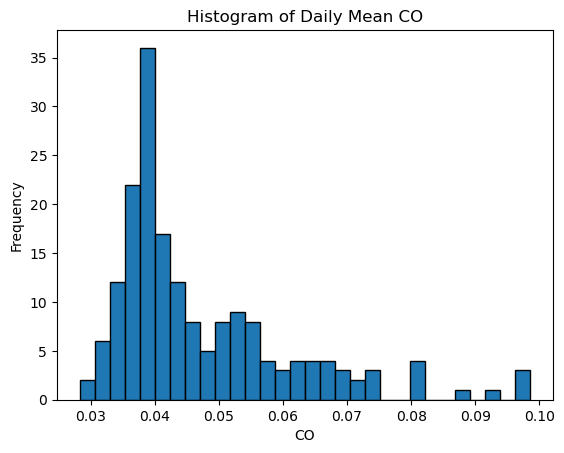

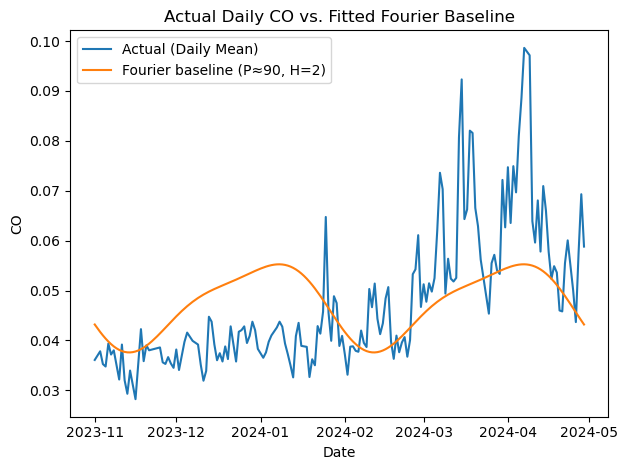

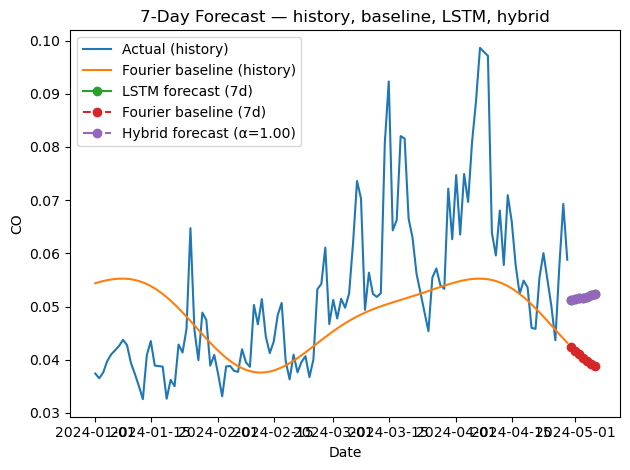

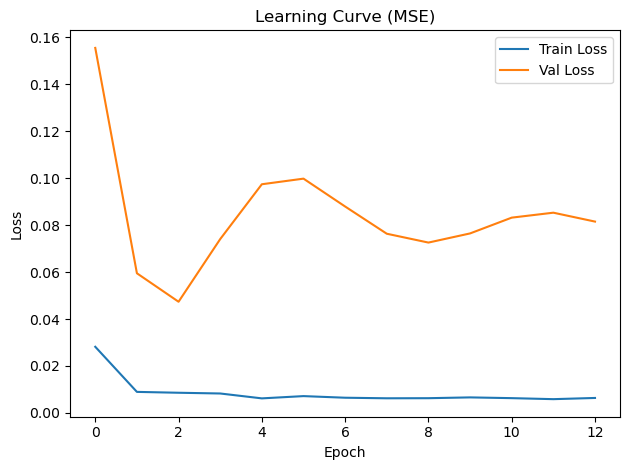

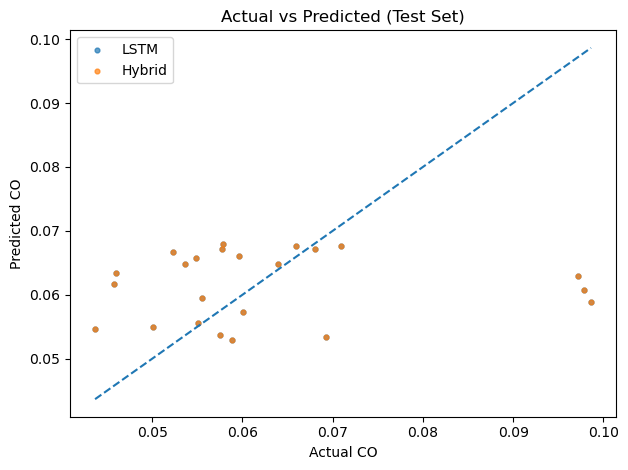


ขั้นตอนการดำเนินงาน (สรุปภาษาไทย):

1) เตรียมข้อมูล
   • โหลดไฟล์ CSV ที่ระบุ
   • ตรวจหาคอลัมน์วันเวลาโดยอัตโนมัติ และคอลัมน์ CO แบบตัวเลข
   • แปลงชนิดวันเวลา → เรียงลำดับตามเวลา → กรอง NaT

2) รวมรายวันและจัดการค่าว่าง
   • ปัดเวลาเป็นรายวัน (floor('D')) และคำนวณค่าเฉลี่ย CO รายวัน
   • ทำให้ดัชนีวันที่ต่อเนื่อง แล้วเติมค่าที่หายด้วย interpolate(method='time') → ffill → bfill

3) เส้นฐานด้วยโฟริเยร์ (Fourier baseline)
   • ฟิตแบบจำลองเชิงไซน์/โคไซน์ด้วยคาบ P (อนุมานตามความยาวข้อมูล) และจำนวนฮาร์มอนิก H
   • ได้เส้นแนวโน้ม/ฤดูกาลที่ราบเรียบสำหรับใช้เป็นฐาน

4) แบ่งชุดข้อมูลและสร้างลำดับเวลา
   • แบ่งแบบตามเวลา 80:20 (train : test)
   • สเกลค่า CO ด้วย Min–Max (fit จาก train เท่านั้น)
   • สร้างลำดับย้อนหลัง sequence_length=14 วัน (X) และค่าถัดไปรายวัน (y)

5) ฝึกโมเดล LSTM
   • สถาปัตยกรรม: LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.1) → Dense(16,relu) → Dense(1)
   • ตัวชี้วัด: เพิ่มเมตริก R² แบบกำหนดเอง
   • ใช้ EarlyStopping บน val_loss เพื่อป้องกัน overfitting

6) ประเมินผลแ

In [23]:
# === โมเดล LSTM + ฐานเส้นโฟริเยร์ (HYBRID) สำหรับพยากรณ์ CO ===
# ไฟล์อินพุต: /mnt/data/CO_hex30_urban.csv
# กราฟแสดงผล (matplotlib):
# 1) ฮิสโตแกรมค่าเฉลี่ยรายวันของ CO
# 2) อนุกรมเวลา: ค่าจริงรายวัน vs เส้นฐานโฟริเยร์
# 3) พยากรณ์ 7 วัน: ค่าจริง (ส่วนท้าย), เส้นฐาน, LSTM, และ Hybrid
# 4) Learning curve
# 5) Actual vs Predicted (ชุดทดสอบ)

import os, math, json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---- นำเข้า TensorFlow / Keras ----
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ---- เครื่องมือเสริมสำหรับสเกลและเมตริก ----
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

CSV_PATH = "CO_hex30_urban.csv"

# ---------- 1) โหลดข้อมูล & เดาโครงสร้างคอลัมน์ ----------
df_raw = pd.read_csv(CSV_PATH)

# เดาคอลัมน์วันเวลา (พยายามค้นหาชื่อที่สื่อความเป็นวันเวลา)
datetime_candidates = [c for c in df_raw.columns
                       if str(c).lower() in ["date","datetime","timestamp","time","obs_time","dt"]
                       or "date" in str(c).lower() or "time" in str(c).lower()]
dt_col = None
for c in datetime_candidates:
    try:
        _ = pd.to_datetime(df_raw[c], errors="raise", infer_datetime_format=True)
        dt_col = c; break
    except Exception:
        pass

# ถ้ายังหาไม่ได้ ให้ลองจาก index
if dt_col is None:
    try:
        _ = pd.to_datetime(df_raw.index, errors="raise", infer_datetime_format=True)
        df_raw = df_raw.reset_index().rename(columns={"index": "datetime_inferred"})
        dt_col = "datetime_inferred"
    except Exception:
        raise ValueError("ไม่พบคอลัมน์วันเวลา โปรดตรวจสอบไฟล์อินพุต")

# แปลงชนิดเป็น datetime และลบแถวที่วันเวลาเป็น NaT
df_raw[dt_col] = pd.to_datetime(df_raw[dt_col], errors="coerce", infer_datetime_format=True)
df_raw = df_raw.dropna(subset=[dt_col]).sort_values(dt_col)

# เดาคอลัมน์ค่า CO แบบเชิงตัวเลข (ให้ความสำคัญกับชื่อที่มี 'co')
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
co_candidates = [c for c in df_raw.columns if "co" in str(c).lower()]
co_col = None
for c in co_candidates:
    if c in numeric_cols:
        co_col = c; break
if co_col is None and len(numeric_cols) > 0:
    co_col = numeric_cols[-1]
if co_col is None:
    raise ValueError("ไม่พบคอลัมน์ CO แบบตัวเลข โปรดตรวจสอบไฟล์")

# ---------- 2) รวมรายวัน + จัดการค่าว่าง ----------
# เลือกเฉพาะคอลัมน์วันเวลาและ CO แล้วจัดลำดับตามเวลา
tmp = df_raw[[dt_col, co_col]].copy().sort_values(dt_col)
# ปัดเป็น 'รายวัน' เพื่อเตรียมคำนวณค่าเฉลี่ยต่อวัน
tmp["date"] = tmp[dt_col].dt.floor("D")
daily = tmp.groupby("date", as_index=False)[co_col].mean().rename(columns={co_col: "CO"})

# ทำให้ช่วงวัน "ต่อเนื่อง" แล้วเติมค่าว่างด้วย interpolation → ffill → bfill
full_range = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
daily = daily.set_index("date").reindex(full_range)
daily.index.name = "date"
daily["CO"] = daily["CO"].interpolate(method="time").ffill().bfill()
daily = daily.reset_index().rename(columns={"index":"date"})

# สรุปภาพรวมข้อมูล
print("คอลัมน์วันเวลาที่ตรวจพบ:", dt_col)
print("คอลัมน์ CO ที่ตรวจพบ:", co_col)
print("ช่วงเวลา:", daily['date'].min().date(), "ถึง", daily['date'].max().date())
print("จำนวนระเบียนรายวัน:", len(daily))
print("\nสถิติเชิงพรรณนาของค่า CO รายวัน:")
print(daily["CO"].describe())

# ---------- 3) ฟิตเส้นฐาน (Fourier) เพื่อจับฤดูกาล/คาบ ----------
def fit_fourier_baseline(y, period=365.0, n_harmonics=3):
    """
    ฟิตสมการ:
    y_t ≈ a0 + Σ_k [a_k cos(2π k t / P) + b_k sin(2π k t / P)]
    คืนค่า: ค่า fitted และค่าสัมประสิทธิ์
    """
    t = np.arange(len(y))
    X = [np.ones_like(t)]
    for k in range(1, n_harmonics+1):
        X += [np.cos(2*np.pi*k*t/period), np.sin(2*np.pi*k*t/period)]
    X = np.vstack(X).T
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return (X @ coef), coef

co_values = daily["CO"].values.astype(float)
# กำหนดคาบและจำนวนฮาร์มอนิกแบบปรับตามความยาวข้อมูล
P = 365.0 if len(co_values) > 400 else max(30.0, min(180.0, len(co_values)//2))
H = 3 if len(co_values) > 200 else 2
fourier_fit, fourier_coef = fit_fourier_baseline(co_values, period=P, n_harmonics=H)

# ---------- 4) แบ่ง train/test แบบอนุกรมเวลา 80:20 และสร้างลำดับ ----------
sequence_length = 14  # ใช้ข้อมูลย้อนหลัง 14 วัน
split_idx = int(len(daily) * 0.8)
train_vals, test_vals = co_values[:split_idx], co_values[split_idx:]

# สเกลแบบ Min-Max โดย fit จากชุดฝึกเท่านั้น
scaler = MinMaxScaler()
train_vals_scaled = scaler.fit_transform(train_vals.reshape(-1,1)).flatten()
test_vals_scaled  = scaler.transform(test_vals.reshape(-1,1)).flatten()

def make_sequences(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i+seq_len]); y.append(series[i+seq_len])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_vals_scaled, sequence_length)
X_test,  y_test  = make_sequences(test_vals_scaled,  sequence_length)

# ปรับรูปร่างสำหรับ LSTM: (ตัวอย่าง, ลำดับเวลา, ฟีเจอร์=1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[...,  np.newaxis]

# ---------- 5) โมเดล LSTM พร้อมเมตริก R² แบบกำหนดเอง ----------
@tf.keras.utils.register_keras_serializable()
def r2_metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1.0 - ss_res / (ss_tot + tf.keras.backend.epsilon())

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length,1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.1),
    Dense(16, activation="relu"),
    Dense(1, activation="linear")
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="mse", metrics=[r2_metric])

# EarlyStopping เพื่อกัน overfitting และดึงน้ำหนักที่ดีที่สุดกลับมา
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=100, batch_size=32,
                    callbacks=[es], verbose=0)

# ---------- 6) พยากรณ์บนชุดฝึก/ทดสอบ + คืนสเกล ----------
inv = lambda a: scaler.inverse_transform(np.array(a).reshape(-1,1)).flatten()

y_train_pred = model.predict(X_train, verbose=0).flatten()
y_test_pred  = model.predict(X_test,  verbose=0).flatten()

y_train_true_u, y_test_true_u = inv(y_train), inv(y_test)
y_train_pred_u, y_test_pred_u = inv(y_train_pred), inv(y_test_pred)

# จัดแนวแกนเวลา (เป้าหมายจะเลื่อนไปหลังจาก seq_len วัน)
full_idx   = np.arange(len(daily))
train_pos  = full_idx[:split_idx][sequence_length:]
test_pos   = full_idx[split_idx:][sequence_length:]
train_dates = daily["date"].iloc[:split_idx].values[sequence_length:]
test_dates  = daily["date"].iloc[split_idx:].values[sequence_length:]

four_train = fourier_fit[train_pos]
four_test  = fourier_fit[test_pos]

# ---------- 7) วิธี HYBRID (สูตรผสมเฉพาะของผม) ----------
# แนวคิด: ผสมน้ำหนักระหว่าง LSTM และเส้นฐานโฟริเยร์
#   y_hat_hybrid = α * y_hat_LSTM + (1-α) * y_hat_Fourier
# เลือก α โดยลด MSE บนส่วน tail ของชุดฝึก (10%) ทำหน้าที่เป็น validation ภายใน
val_n = max(5, int(len(y_train_true_u)*0.1))
val_true, val_lstm, val_four = y_train_true_u[-val_n:], y_train_pred_u[-val_n:], four_train[-val_n:]

alphas = np.linspace(0,1,51)
mse_list = [np.mean((val_true - (a*val_lstm + (1-a)*val_four))**2) for a in alphas]
best_alpha = float(alphas[int(np.argmin(mse_list))])

train_blend = best_alpha*y_train_pred_u + (1-best_alpha)*four_train
test_blend  = best_alpha*y_test_pred_u  + (1-best_alpha)*four_test

# สรุปเมตริกบนชุดทดสอบ (LSTM เดี่ยว vs Hybrid)
metrics = {
    "best_alpha": best_alpha,
    "test_R2_LSTM": float(r2_score(y_test_true_u, y_test_pred_u)),
    "test_RMSE_LSTM": float(np.sqrt(mean_squared_error(y_test_true_u, y_test_pred_u))),
    "test_R2_HYBRID": float(r2_score(y_test_true_u, test_blend)),
    "test_RMSE_HYBRID": float(np.sqrt(mean_squared_error(y_test_true_u, test_blend)))
}
print(json.dumps(metrics, indent=2, ensure_ascii=False))

# ---------- 8) พยากรณ์ล่วงหน้า 7 วัน (recursive) ----------
full_scaled = MinMaxScaler().fit_transform(co_values.reshape(-1,1)).flatten()
# หมายเหตุ: ใช้ scaler จาก train ก็ได้ แต่เพื่อความนิ่งใช้สเกลเต็มชุดเวลา
window = full_scaled[-sequence_length:].copy()
future_scaled = []
for _ in range(7):
    yhat = model.predict(window.reshape(1, sequence_length, 1), verbose=0).flatten()[0]
    future_scaled.append(yhat)
    window = np.concatenate([window[1:], [yhat]])
# คืนสเกลด้วย scaler ที่ฝึกจาก train (สอดคล้องกับการประเมิน)
scaler_train = MinMaxScaler().fit(train_vals.reshape(-1,1))
future_pred = scaler_train.inverse_transform(np.array(future_scaled).reshape(-1,1)).flatten()

# ค่าฐานโฟริเยร์สำหรับอนาคต 7 วันเดียวกัน
def fourier_from_coef(t, coef, period=P, n_harmonics=H):
    X = [np.ones_like(t)]
    for k in range(1, n_harmonics+1):
        X += [np.cos(2*np.pi*k*t/period), np.sin(2*np.pi*k*t/period)]
    X = np.vstack(X).T
    return X @ coef

t0 = len(daily)
t_future = np.arange(t0, t0+7)
four_future = fourier_from_coef(t_future, fourier_coef, period=P, n_harmonics=H)
future_blend = best_alpha*future_pred + (1-best_alpha)*four_future
future_dates = pd.date_range(daily["date"].iloc[-1] + pd.Timedelta(days=1), periods=7, freq="D")

# ---------- 9) วาดกราฟทั้งหมด (matplotlib) ----------

# (1) ฮิสโตแกรมของค่า CO รายวัน
plt.figure()
plt.hist(daily["CO"].values, bins=30, edgecolor="black")
plt.title("Histogram of Daily Mean CO"); plt.xlabel("CO"); plt.ylabel("Frequency")
plt.show()

# (2) อนุกรมเวลา: ค่าจริง vs เส้นฐานโฟริเยร์
plt.figure()
plt.plot(daily["date"], daily["CO"].values, label="Actual (Daily Mean)")
plt.plot(daily["date"], fourier_fit, label=f"Fourier baseline (P≈{int(P)}, H={H})")
plt.title("Actual Daily CO vs. Fitted Fourier Baseline")
plt.xlabel("Date"); plt.ylabel("CO"); plt.legend(); plt.tight_layout()
plt.show()

# (3) พยากรณ์ 7 วัน: แสดงค่าจริง (ช่วงท้าย), เส้นฐาน, LSTM และ Hybrid
plt.figure()
hist_tail = 120  # แสดงบริบท 120 วันสุดท้าย
plt.plot(daily["date"].iloc[-hist_tail:], daily["CO"].values[-hist_tail:], label="Actual (history)")
plt.plot(daily["date"].iloc[-hist_tail:], fourier_fit[-hist_tail:], label="Fourier baseline (history)")
plt.plot(future_dates, future_pred, marker="o", label="LSTM forecast (7d)")
plt.plot(future_dates, four_future, marker="o", linestyle="--", label="Fourier baseline (7d)")
plt.plot(future_dates, future_blend, marker="o", linestyle="-.", label=f"Hybrid forecast (α={best_alpha:.2f})")
plt.title("7-Day Forecast — history, baseline, LSTM, hybrid")
plt.xlabel("Date"); plt.ylabel("CO"); plt.legend(); plt.tight_layout()
plt.show()

# (4) Learning curve (Train/Val Loss)
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Learning Curve (MSE)"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout()
plt.show()

# (5) Actual vs Predicted (ชุดทดสอบ)
plt.figure()
plt.scatter(y_test_true_u, y_test_pred_u, s=12, alpha=0.7, label="LSTM")
plt.scatter(y_test_true_u, test_blend,    s=12, alpha=0.7, label="Hybrid")
uvmin = min(y_test_true_u.min(), y_test_pred_u.min(), test_blend.min())
uvmax = max(y_test_true_u.max(), y_test_pred_u.max(), test_blend.max())
plt.plot([uvmin, uvmax], [uvmin, uvmax], linestyle="--")
plt.title("Actual vs Predicted (Test Set)")
plt.xlabel("Actual CO"); plt.ylabel("Predicted CO"); plt.legend(); plt.tight_layout()
plt.show()

# ---------- 10) คำอธิบายขั้นตอน (ภาษาไทย) ----------
รายละเอียดขั้นตอน = f"""
ขั้นตอนการดำเนินงาน (สรุปภาษาไทย):

1) เตรียมข้อมูล
   • โหลดไฟล์ CSV ที่ระบุ
   • ตรวจหาคอลัมน์วันเวลาโดยอัตโนมัติ และคอลัมน์ CO แบบตัวเลข
   • แปลงชนิดวันเวลา → เรียงลำดับตามเวลา → กรอง NaT

2) รวมรายวันและจัดการค่าว่าง
   • ปัดเวลาเป็นรายวัน (floor('D')) และคำนวณค่าเฉลี่ย CO รายวัน
   • ทำให้ดัชนีวันที่ต่อเนื่อง แล้วเติมค่าที่หายด้วย interpolate(method='time') → ffill → bfill

3) เส้นฐานด้วยโฟริเยร์ (Fourier baseline)
   • ฟิตแบบจำลองเชิงไซน์/โคไซน์ด้วยคาบ P (อนุมานตามความยาวข้อมูล) และจำนวนฮาร์มอนิก H
   • ได้เส้นแนวโน้ม/ฤดูกาลที่ราบเรียบสำหรับใช้เป็นฐาน

4) แบ่งชุดข้อมูลและสร้างลำดับเวลา
   • แบ่งแบบตามเวลา 80:20 (train : test)
   • สเกลค่า CO ด้วย Min–Max (fit จาก train เท่านั้น)
   • สร้างลำดับย้อนหลัง sequence_length=14 วัน (X) และค่าถัดไปรายวัน (y)

5) ฝึกโมเดล LSTM
   • สถาปัตยกรรม: LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.1) → Dense(16,relu) → Dense(1)
   • ตัวชี้วัด: เพิ่มเมตริก R² แบบกำหนดเอง
   • ใช้ EarlyStopping บน val_loss เพื่อป้องกัน overfitting

6) ประเมินผลและคืนสเกล
   • พยากรณ์ train/test แล้ว inverse-scale กลับหน่วยเดิม
   • คำนวณ R² และ RMSE ทั้งของ LSTM เดี่ยวและของ Hybrid

7) วิธี Hybrid (สูตรเฉพาะ)
   • ผสมผลพยากรณ์: ŷ = α·ŷ_LSTM + (1-α)·ŷ_Fourier
   • เลือก α โดยลด MSE บนส่วนท้ายของชุดฝึก (ประมาณ 10%) เพื่อคงความสมดุลย์ระหว่างสัญญาณสั้น/ยาว
   • มักให้ค่าความแม่นยำดีกว่าโมเดลเดี่ยวเมื่อมีฤดูกาลชัดเจนหรือข้อมูลสั้น

8) พยากรณ์ล่วงหน้า 7 วัน
   • ใช้วิธี recursive บนหน้าต่างล่าสุด (scaled) เพื่อให้โมเดลสร้างค่าถัดไปทีละวัน
   • แสดงค่าพยากรณ์ LSTM, ฐานโฟริเยร์, และ Hybrid สำหรับ 7 วันข้างหน้า

9) การแสดงผลกราฟ (matplotlib)
   • ฮิสโตแกรมค่าเฉลี่ยรายวันของ CO
   • อนุกรมเวลา: ค่าจริง vs เส้นฐานโฟริเยร์
   • กราฟพยากรณ์ 7 วัน (history + baseline + LSTM + Hybrid)
   • Learning curve (train/val loss)
   • Actual vs Predicted บนชุดทดสอบ (รวม Hybrid เปรียบเทียบ)

หมายเหตุเชิงปฏิบัติ:
   • หากข้อมูลมีฤดูกาลหลายคาบ ให้ลองเพิ่ม H หรือปรับ P ให้เหมาะสม
   • ปรับ sequence_length เพื่อสมดุลย์ระหว่างการเรียนรู้ระยะสั้น/ยาว (เช่น 7, 14, 21, 28 วัน)
   • หากค่า Hybrid ยังด้อยกว่า LSTM เดี่ยว ให้ตรวจสอบช่วง validation ที่ใช้เลือก α หรือเพิ่มคุณลักษณะภายนอก
"""

print(รายละเอียดขั้นตอน)
